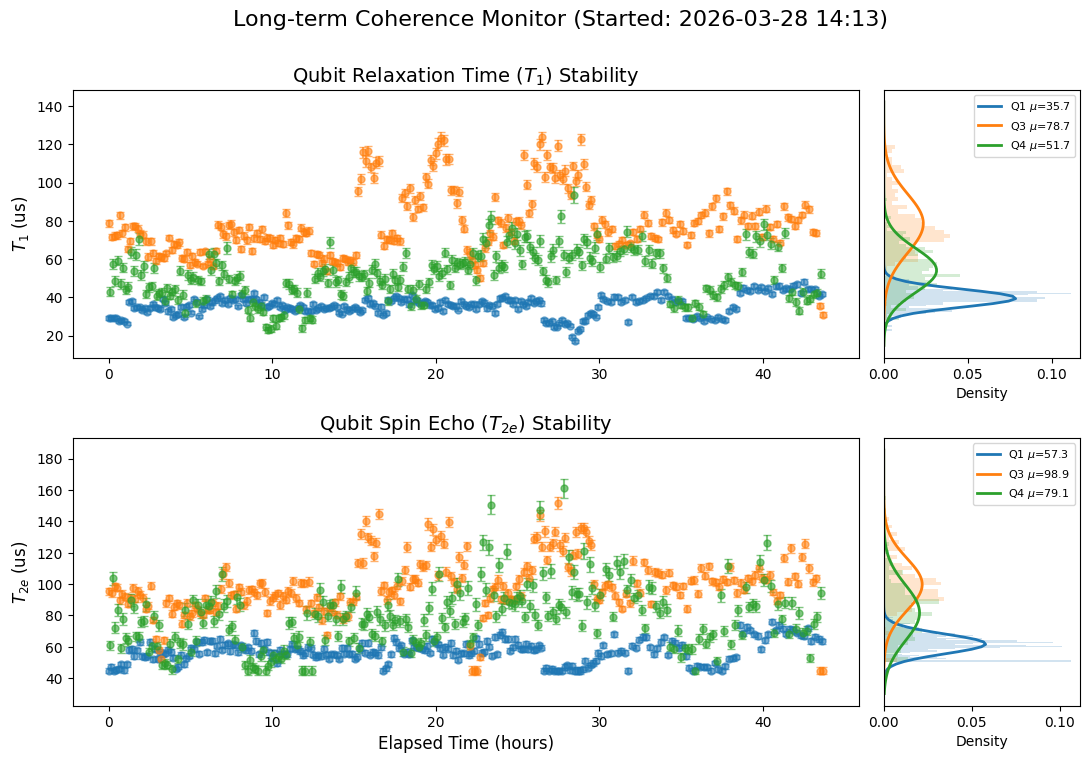

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.stats import norm

# settings
csv_path = "qubit_monitor_data.csv"

def plot_full_coherence_monitor(path):
    if not os.path.exists(path):
        print(f"error: {path} not found")
        return

    # 1. 載入數據與時間換算
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # 計算相對小時 (從第一筆數據開始算作 0 小時)
    start_time = df['timestamp'].min()
    df['hours'] = (df['timestamp'] - start_time).dt.total_seconds() / 3600.0
    
    qubits = df['qubit'].unique()
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    # 2. 設定 2x2 佈局 (左邊是時序圖，右邊是分佈圖)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), 
                             gridspec_kw={'width_ratios': [4, 1], 'hspace': 0.3, 'wspace': 0.05})
    
    # 定義要畫的項目 (欄位名稱, 誤差欄位, 單位, 軸名稱)
    metrics = [
        ('t1_time', 't1_err', '$T_1$ (us)', axes[0]),
        ('t2e_time', 't2e_err', '$T_{2e}$ (us)', axes[1])
    ]

    for row_idx, (val_col, err_col, ylabel, row_axes) in enumerate(metrics):
        ax_scatter, ax_hist = row_axes
        
        # 用於動態調整直方圖的 Y 軸範圍
        all_vals = df[val_col].dropna()
        y_min, y_max = all_vals.min() * 0.5, all_vals.max() * 1.2
        y_range = np.linspace(y_min, y_max, 100)

        for i, q_name in enumerate(qubits):
            q_data = df[df['qubit'] == q_name].sort_values('hours')
            vals = q_data[val_col].values
            errs = q_data[err_col].values
            color = colors[i % len(colors)]
            
            # --- 左側：時序散點圖 (X 軸為 Hour) ---
            ax_scatter.errorbar(
                q_data['hours'], vals, yerr=errs,
                fmt='o', markersize=5, capsize=3, alpha=0.6,
                color=color, label=q_name if row_idx == 0 else "" # 僅第一列顯示 legend 防止重複
            )
            
            # --- 右側：水平直方圖 ---
            ax_hist.hist(vals, bins=40, orientation='horizontal', 
                         alpha=0.2, color=color, density=True)
            
            # 高斯擬合
            if len(vals) > 1:
                mu, std = norm.fit(vals)
                p = norm.pdf(y_range, mu, std)
                ax_hist.plot(p, y_range, color=color, linewidth=2, 
                             label=f'{q_name} $\mu$={mu:.1f}')

        # 格式化
        ax_scatter.set_ylabel(ylabel, fontsize=12)
        ax_scatter.set_ylim(y_min, y_max)

        ax_hist.set_xlabel("Density")

        ax_hist.tick_params(left=False, labelleft=False)
        
        if row_idx == 0:
            ax_scatter.set_title("Qubit Relaxation Time ($T_1$) Stability", fontsize=14)
            # ax_scatter.legend(loc='upper left', bbox_to_anchor=(0, 1.15), ncol=len(qubits))
            ax_hist.legend(fontsize=8, loc='upper right')
        else:
            ax_scatter.set_title("Qubit Spin Echo ($T_{2e}$) Stability", fontsize=14)
            ax_scatter.set_xlabel("Elapsed Time (hours)", fontsize=12)
            ax_hist.legend(fontsize=8, loc='upper right')

    plt.suptitle(f"Long-term Coherence Monitor (Started: {start_time.strftime('%Y-%m-%d %H:%M')})", 
                 fontsize=16, y=0.98)
    plt.show()

# 執行
plot_full_coherence_monitor(csv_path)